<a href="https://colab.research.google.com/github/luciavilchez23/SimulacionPAS/blob/main/Simulaci%C3%B3nPAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PASEO ALEATORIO SIMPLE

Voy a simular trayectorias del proceso estocástico PAS.

Para cada $t$ natural se considera $X_t=\sum_{s=1}^∞ Z_s$ donde las variables aleatorias $Z_s$ son independientes e idénticamente distribuidas según la distribución:
$P(Z_s=1)=p$ y $P(Z_s=-1)=1-p$.

Podemos interpretar $X_t$ como la posición de una partícula en el instante $t$ que se mueve en un espacio $1$-dimensional de manera aleatoria.

## Función que simula el PAS

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

El primer paso es definir una función que simule el PAS. Esta función va a recibir tres argumentos:
- $p$: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor $1$ en cada paso.
- $n$: es el número de pasos a simular para cada trayectoria.
- reps: se refiere al número de trayectorias a simular.

In [ ]:
def simular_PAS(p,n,reps=1): #reps=1 para que si no se especifica como argumento siempre haga al menos una trayectoria

  # primero genero un array de shape (reps,n) con números aleatorios entre 0 y 1
  matriz = np.random.rand(reps,n)
  # matriz = np.random.choice([1, -1], size = (reps, n), p = [p, 1-p]) da directamente la matriz de 1 y -1 con la probabilidad adecuada en cada caso

  # ahora me preocupo por cambiar los valores menores que p por 1 y los mayores que p por -1
  pasos = np.where(matriz < p, 1, -1) #np.where(condición,valor_true,valor_false) es una forma de cambiar los valores de un array en función de si cumplen o no cierta condición, también podría haberlo hecho con bucles

  # NOTA: el shape tanto de matriz como de pasos es (reps,n)

  # ahora sumamos para saber que valor tiene en cada posición
  trayectorias = np.cumsum(np.insert(pasos, 0, 0, axis=1), axis=1) # va a hacer la suma acumulada en cada posición, axis=1 se refiere a que suma por filas,así no mezcla trayectorias, np.insert() para que todas empiecen en 0
  return trayectorias # shape: (reps,n)

## Visualización 1: sin media ni desviación típica teóricas

### Visualización de la diapositiva 16

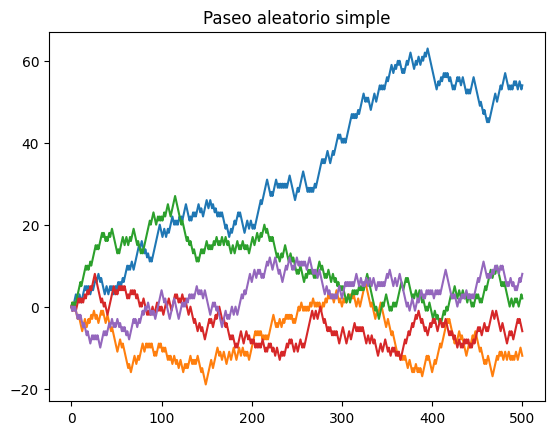

In [ ]:
p = 0.5
n = 500
reps = 5
grafica1 = simular_PAS(p, n, reps)
for i in range(reps):
  plt.plot(grafica1[i])

plt.title("Paseo aleatorio simple");

### Visualización de la diapositiva 17

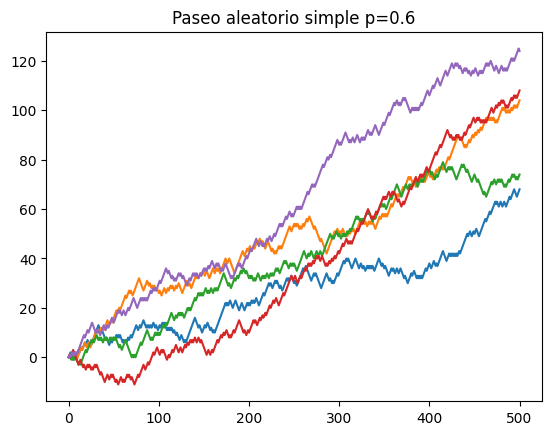

In [ ]:
p = 0.6
grafica2 = simular_PAS(p,n,reps)
for i in range(reps):
  plt.plot(grafica2[i])

plt.title("Paseo aleatorio simple p=0.6");


### Visualización de la diapositiva 18

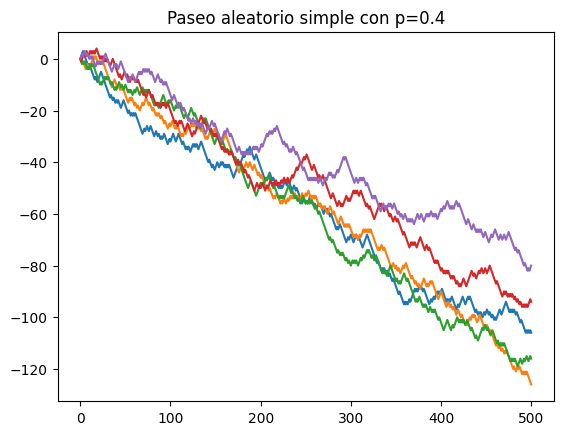

In [ ]:
p = 0.4
grafica3 = simular_PAS(p,n,reps)
for i in range(reps):
  plt.plot(grafica3[i])

plt.title("Paseo aleatorio simple con p=0.4");

## Visualización 2: con media y desviación típica teóricas

### Visualización de la diapositiva 30

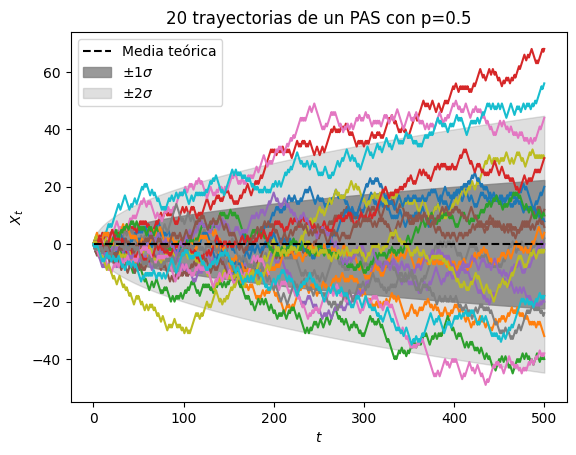

In [ ]:
p = 0.5
n = 500
reps = 20

# Cálculo de la media teórica
t = np.arange(1, n+1) # eje temporal, t = {1,2,3,...,n}
media = (2*p - 1) * t

# Cálculo de la desviación típica teórica
desv_tipica = np.sqrt(4*p*(1-p)*t)

# Hago la gráfica
grafica4 = simular_PAS(p,n,reps)
for i in range(reps):
  plt.plot(grafica4[i])

plt.plot(t, media, 'k--', label = 'Media teórica') # dibuja la media teórica
# dibuja las zonas sombreadas pedidas
plt.fill_between(t, media - desv_tipica, media + desv_tipica, color = 'gray', alpha = 0.8, label = r"$\pm 1\sigma$") # debo poner una r antes de las comillas pues al escribir en LATEX después me da un warning, con la r evito el mensaje
plt.fill_between(t, media - 2*desv_tipica, media + 2*desv_tipica, color = 'gray', alpha = 0.25, label = r"$\pm 2\sigma$")

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.5");

### Visualización de la diapositiva 31

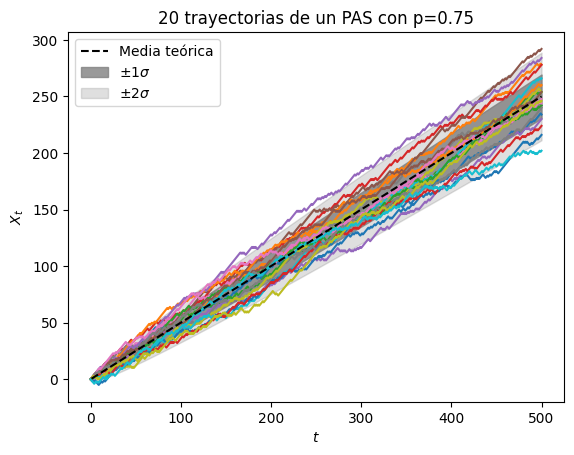

In [ ]:
p = 0.75
n = 500
reps = 20

# Cálculo de la media teórica
t = np.arange(1, n+1) # eje temporal, t = {1,2,3,...,n}
media = (2 * p - 1) * t

# Cálculo de la desviación típica teórica
desv_tipica = np.sqrt(4*p*(1-p)*t)

# Hago la gráfica
grafica5 = simular_PAS(p,n,reps)
for i in range(reps):
  plt.plot(grafica5[i])

plt.plot(t, media, 'k--', label = "Media teórica")
plt.fill_between(t, media - desv_tipica, media + desv_tipica, color = 'gray', alpha = 0.8, label = r"$\pm 1\sigma$")
plt.fill_between(t, media - 2*desv_tipica, media + 2*desv_tipica, color = 'gray', alpha = 0.25, label = r"$\pm 2\sigma$")

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.75");

### Visualización de la diapositiva 32

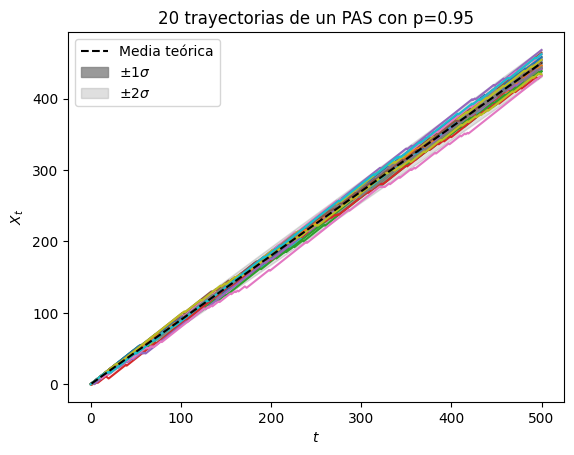

In [ ]:
p = 0.95
n = 500
reps = 20

# Cálculo de la media teórica
t = np.arange(1, n+1) # eje temporal, t = {1,2,3,...,n}
media = (2*p - 1) * t

# Cálculo de la desviación típica teórica
desv_tipica = np.sqrt(4*p*(1-p)*t)

# Hago la gráfica
grafica6 = simular_PAS(p,n,reps)
for i in range(reps):
  plt.plot(grafica6[i])

plt.plot(t, media, 'k--', label = "Media teórica")
plt.fill_between(t, media - desv_tipica, media + desv_tipica, color = 'gray', alpha = 0.8, label = r"$\pm 1\sigma$")
plt.fill_between(t, media - 2*desv_tipica, media + 2*desv_tipica, color = 'gray', alpha = 0.25, label = r"$\pm 2\sigma$")

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.95");

## Visualización 3: media empírica y teórica cuando aumentamos el número de trayectorias

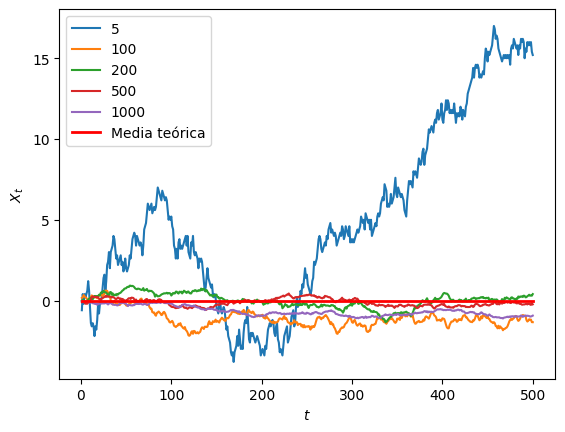

In [ ]:
p = 0.5
n = 500

t = np.arange(1, n+1)
media = (2*p - 1) * t

# Creo una lista con el número de trayectorias
lista_reps = [5, 100, 200, 500, 1000]

# Con ayuda de un bucle for grafico las medias empíricas de cada trayectoria
for reps in lista_reps:
  grafica7 = simular_PAS(p,n,reps)
  media_empirica = np.mean(grafica7, axis = 0)[1:] # me deslizo una posición más para evitar coger el valor en t=0
  plt.plot(t, media_empirica, label = str(reps))

# Sobre ella grafico la media teórica
plt.plot(t, media, 'r', linewidth = 2, label = "Media teórica")

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$X_t$");